# Assignment: Sentiment Analysis using NLP Pipeline & ML Models


## Objective

Build a complete end-to-end Sentiment Analysis system by applying NLP preprocessing, feature engineering, and multiple Machine Learning models. Compare their performance using evaluation metrics.


## Task Description

You are required to build a Sentiment Analysis model using a real-world dataset from Kaggle. The goal is to understand how raw text is processed, transformed into features, and used in ML models.


## Dataset Requirement
Source: Kaggle
Examples:
- IMDb Reviews Dataset
- Amazon Reviews
- Twitter Sentiment Dataset

The dataset must contain text data with sentiment labels (Positive/Negative/Neutral).


### Task Breakdown
1. Data Understanding
Load dataset, explore number of samples, class distribution, and sample texts.

2. NLP Preprocessing (Mandatory)
Lowercasing
Removing punctuation
Removing stopwords
Tokenization
Stemming or Lemmatization
Handling special characters/URLs
Create reusable functions.

3. Feature Engineering
Convert text using Bag of Words (BoW) and TF-IDF.
Optional: Word2Vec / Avg Word2Vec.

4. Model Building
Train at least 3 models:
- Logistic Regression
- Naive Bayes
- Decision Tree
Optional: Random Forest, XGBoost.

5. Model Evaluation
Evaluate using Accuracy, Precision, Recall, and F1 Score.
Compare performance across models.

6. Comparison & Insights
Explain best preprocessing steps, best vectorization, best model, and trade-offs.
Expected Pipeline Flow
Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Comparison


#### Sentiment Analysis using NLP Pipeline & ML Models

Dataset: IMDb Top 1000 Movies (imdb_top_1000.csv)
Text column used: Overview (movie plot descriptions)
Sentiment derived from IMDB_Rating:

Rating ≥ 8.2 → Positive
Rating 7.8 – 8.19 → Neutral
Rating < 7.8 → Negative
Pipeline Flow
Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Comparison

In [2]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model  import LogisticRegression
from sklearn.naive_bayes   import MultinomialNB
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

print('All libraries imported successfully!')

All libraries imported successfully!


## Section 1: Data Understanding

Load dataset, explore number of samples, class distribution, and sample texts.


In [7]:
# Load dataset
df = pd.read_csv(r"/Users/srivinayvatti/Downloads/imdb_top_1000.csv")

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(5)

Shape: (1000, 16)
Columns: ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [8]:
# Basic info
print(df.info())
print('\nNull values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB
None

Null values:
 Poster_Link      

IMDB_Rating statistics:
count    1000.000000
mean        7.949300
std         0.275491
min         7.600000
25%         7.700000
50%         7.900000
75%         8.100000
max         9.300000
Name: IMDB_Rating, dtype: float64


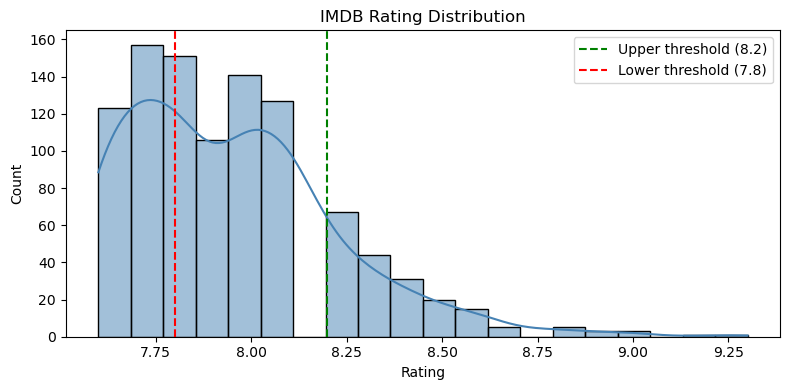

In [9]:
# IMDB_Rating distribution
print('IMDB_Rating statistics:')
print(df['IMDB_Rating'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df['IMDB_Rating'], bins=20, kde=True, color='steelblue')
plt.axvline(x=8.2, color='green', linestyle='--', label='Upper threshold (8.2)')
plt.axvline(x=7.8, color='red',   linestyle='--', label='Lower threshold (7.8)')
plt.title('IMDB Rating Distribution')
plt.xlabel('Rating')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Derive sentiment labels from IMDB_Rating
def assign_sentiment(rating):
    if rating >= 8.2:
        return 'Positive'
    elif rating >= 7.8:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['IMDB_Rating'].apply(assign_sentiment)

# Numeric encoding for ML models
label_map   = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['sentiment'].map(label_map)

print('Sentiment class distribution:')
print(df['sentiment'].value_counts())

Sentiment class distribution:
sentiment
Neutral     525
Negative    280
Positive    195
Name: count, dtype: int64


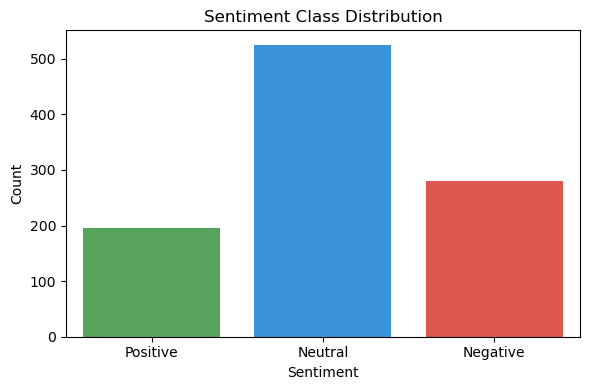

In [11]:
# Class distribution bar chart
plt.figure(figsize=(6, 4))
order = ['Positive', 'Neutral', 'Negative']
sns.countplot(x='sentiment', data=df, order=order,
              palette={'Positive':'#4CAF50', 'Neutral':'#2196F3', 'Negative':'#F44336'})
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [12]:
# Sample texts from each class
for sent in ['Positive', 'Neutral', 'Negative']:
    row = df[df['sentiment'] == sent][['Series_Title','IMDB_Rating','Overview']].iloc[0]
    print(f"[{sent}] {row['Series_Title']} (Rating: {row['IMDB_Rating']})")
    print(f"  Overview: {row['Overview']}\n")
    

[Positive] The Shawshank Redemption (Rating: 9.3)
  Overview: Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.

[Neutral] Portrait de la jeune fille en feu (Rating: 8.1)
  Overview: On an isolated island in Brittany at the end of the eighteenth century, a female painter is obliged to paint a wedding portrait of a young woman.

[Negative] Roma (Rating: 7.7)
  Overview: A year in the life of a middle-class family's maid in Mexico City in the early 1970s.



## Section 2: NLP Preprocessing

Each step is a standalone reusable function, then composed into a full pipeline.

In [14]:
# Initialise NLP tools
STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Step 1: Lowercase
def to_lowercase(text):
    """Convert all characters to lowercase."""
    return text.lower()

# Step 2: Remove URLs
def remove_urls(text):
    """Remove http/https links and www addresses."""
    return re.sub(r'http\S+|www\.\S+', '', text)

# Step 3: Remove HTML tags
def remove_html(text):
    """Strip residual HTML tags."""
    return re.sub(r'<[^>]+>', '', text)

# Step 4: Remove special characters & numbers
def remove_special_chars(text):
    """Keep only alphabetic characters and spaces."""
    return re.sub(r'[^a-z\s]', '', text)

# Step 5: Remove punctuation
def remove_punctuation(text):
    """Remove all punctuation marks."""
    return text.translate(str.maketrans('', '', string.punctuation))

# Step 6: Tokenise
def tokenize(text):
    """Split text into word tokens."""
    return word_tokenize(text)

# Step 7: Remove stopwords
def remove_stopwords(tokens):
    """Filter out common English stopwords and single characters."""
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

# Step 8a: Stemming
def apply_stemming(tokens):
    """Reduce words to root form using Porter Stemmer."""
    return [stemmer.stem(t) for t in tokens]

# Step 8b: Lemmatization
def apply_lemmatization(tokens):
    """Reduce words to base form using WordNet Lemmatizer."""
    return [lemmatizer.lemmatize(t) for t in tokens]

# Full pipeline
def preprocess(text, use_stemming=False):
    """
    Complete NLP preprocessing pipeline.
    Args:
        text         : raw input string
        use_stemming : True -> stemming | False -> lemmatization (default)
    Returns:
        Cleaned string ready for vectorisation.
    """
    text   = to_lowercase(text)
    text   = remove_urls(text)
    text   = remove_html(text)
    text   = remove_special_chars(text)
    text   = remove_punctuation(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = apply_stemming(tokens) if use_stemming else apply_lemmatization(tokens)
    return ' '.join(tokens)

print('All preprocessing functions defined.')

All preprocessing functions defined.


In [15]:
# Demo: before vs after
sample_raw = df['Overview'].iloc[0]
print('RAW TEXT:')
print(sample_raw)
print('\nCLEANED (lemmatization):')
print(preprocess(sample_raw))
print('\nCLEANED (stemming):')
print(preprocess(sample_raw, use_stemming=True))

RAW TEXT:
Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.

CLEANED (lemmatization):
two imprisoned men bond number year finding solace eventual redemption act common decency

CLEANED (stemming):
two imprison men bond number year find solac eventu redempt act common decenc


In [16]:
# Apply preprocessing to whole dataset
df = df.dropna(subset=['Overview']).reset_index(drop=True)

print('Applying preprocessing...')
df['cleaned_overview'] = df['Overview'].apply(preprocess)
print('Done!')

df[['Series_Title','sentiment','Overview','cleaned_overview']].head(3)

Applying preprocessing...
Done!


,Series_Title,sentiment,Overview,cleaned_overview
0,The Shawshank Redemption,Positive,Two imprisoned men bond over a number of years...,two imprisoned men bond number year finding so...
1,The Godfather,Positive,An organized crime dynasty's aging patriarch t...,organized crime dynasty aging patriarch transf...
2,The Dark Knight,Positive,When the menace known as the Joker wreaks havo...,menace known joker wreaks havoc chaos people g...


## Section 3: Feature Engineering

- **Bag of Words (BoW):** Raw word counts
- **TF-IDF:** Weights terms by uniqueness across documents

In [17]:
# Train-test split BEFORE vectorisation (prevents data leakage)
X = df['cleaned_overview']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 800 | Test: 200


In [18]:
# Bag of Words (unigrams + bigrams)
bow_vectorizer  = CountVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_bow     = bow_vectorizer.fit_transform(X_train)
X_test_bow      = bow_vectorizer.transform(X_test)
print('BoW matrix shape (train):', X_train_bow.shape)

BoW matrix shape (train): (800, 3000)


In [19]:
# TF-IDF (unigrams + bigrams)
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf    = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf     = tfidf_vectorizer.transform(X_test)
print('TF-IDF matrix shape (train):', X_train_tfidf.shape)

TF-IDF matrix shape (train): (800, 3000)


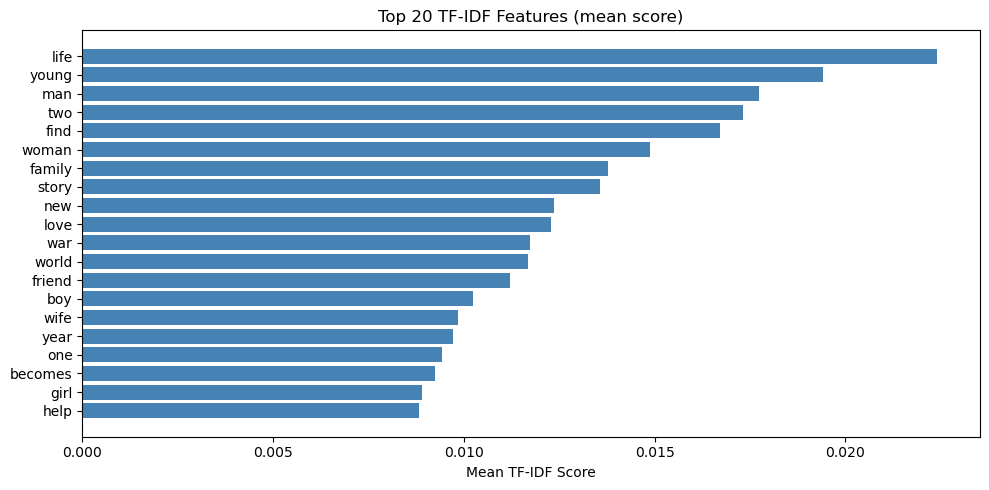

In [20]:
# Top 20 TF-IDF features by mean score
feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf    = X_train_tfidf.mean(axis=0).A1
top20_idx     = mean_tfidf.argsort()[::-1][:20]

plt.figure(figsize=(10, 5))
plt.barh([feature_names[i] for i in top20_idx[::-1]],
         mean_tfidf[top20_idx[::-1]], color='steelblue')
plt.title('Top 20 TF-IDF Features (mean score)')
plt.xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.show()

## Section 4: Model Building

Training 4 models × 2 vectorisers = 8 combinations total.

In [21]:
# Helper: train and evaluate
def train_evaluate(model, X_tr, X_te, y_tr, y_te, label=''):
    """Fit model, predict, return metrics dict and predictions."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model'    : label,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred,    average='weighted', zero_division=0), 4),
        'F1 Score' : round(f1_score(y_te, y_pred,        average='weighted', zero_division=0), 4),
    }, y_pred

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [22]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'        : MultinomialNB(),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, max_depth=15,
                                                   random_state=42, n_jobs=-1),
}

all_results, all_preds = [], {}

for vec_name, (X_tr, X_te) in [('BoW',   (X_train_bow,   X_test_bow)),
                                 ('TF-IDF',(X_train_tfidf, X_test_tfidf))]:
    for model_name, model in models.items():
        label = f'{model_name} ({vec_name})'
        metrics, y_pred = train_evaluate(model, X_tr, X_te, y_train, y_test, label)
        all_results.append(metrics)
        all_preds[label] = y_pred
        print(f'Trained: {label}')

results_df = pd.DataFrame(all_results)
print('\nAll models trained!')

Trained: Logistic Regression (BoW)
Trained: Naive Bayes (BoW)
Trained: Decision Tree (BoW)
Trained: Random Forest (BoW)
Trained: Logistic Regression (TF-IDF)
Trained: Naive Bayes (TF-IDF)
Trained: Decision Tree (TF-IDF)
Trained: Random Forest (TF-IDF)

All models trained!


## Section 5: Model Evaluation

In [23]:
# Results table sorted by F1 Score
results_sorted = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
print('Model Performance Summary (sorted by F1 Score):')
results_sorted

Model Performance Summary (sorted by F1 Score):


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (BoW),0.485,0.4407,0.485,0.4464
1,Naive Bayes (BoW),0.455,0.3802,0.455,0.4010
2,Decision Tree (TF-IDF),0.480,0.4007,0.480,0.3941
3,Logistic Regression (TF-IDF),0.515,0.5050,0.515,0.3902
4,Decision Tree (BoW),0.485,0.3675,0.485,0.3764
5,Random Forest (BoW),0.525,0.2756,0.525,0.3615
6,Random Forest (TF-IDF),0.525,0.2756,0.525,0.3615
7,Naive Bayes (TF-IDF),0.520,0.2744,0.520,0.3592


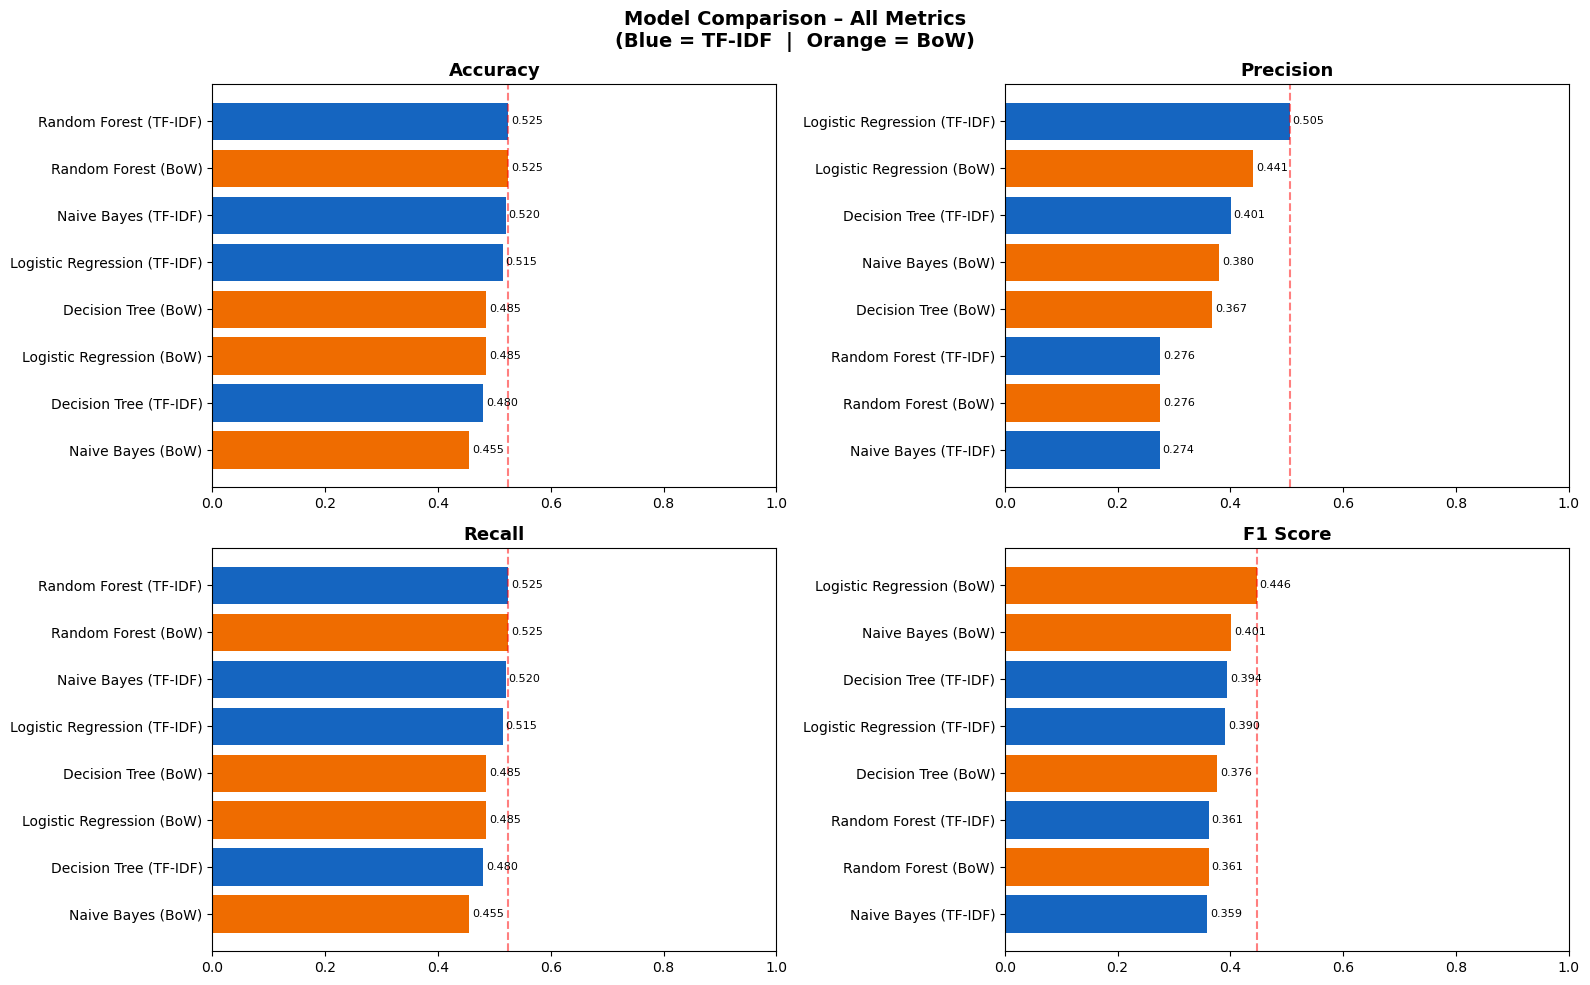

In [24]:
# Bar chart: all 4 metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sub    = results_df.sort_values(metric, ascending=True)
    colors = ['#1565C0' if 'TF-IDF' in m else '#EF6C00' for m in sub['Model']]
    axes[i].barh(sub['Model'], sub[metric], color=colors)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_xlim(0, 1)
    axes[i].axvline(sub[metric].max(), color='red', linestyle='--', alpha=0.5)
    for j, val in enumerate(sub[metric]):
        axes[i].text(val + 0.005, j, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Model Comparison – All Metrics\n(Blue = TF-IDF  |  Orange = BoW)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Best model: classification report
best_label = results_sorted.iloc[0]['Model']
print(f'Best model: {best_label}\n')
print(classification_report(
    y_test, all_preds[best_label],
    target_names=['Negative','Neutral','Positive']))

Best model: Logistic Regression (BoW)

              precision    recall  f1-score   support

    Negative       0.24      0.14      0.18        56
     Neutral       0.55      0.75      0.63       105
    Positive       0.43      0.26      0.32        39

    accuracy                           0.48       200
   macro avg       0.41      0.38      0.38       200
weighted avg       0.44      0.48      0.45       200



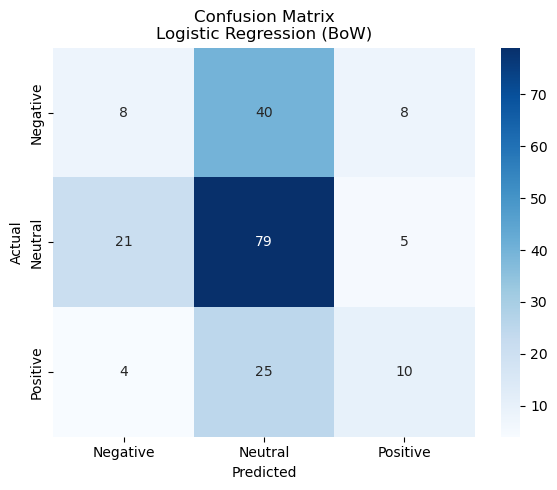

In [26]:
# Best model: confusion matrix
cm = confusion_matrix(y_test, all_preds[best_label])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title(f'Confusion Matrix\n{best_label}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Section 6: Comparison & Insights

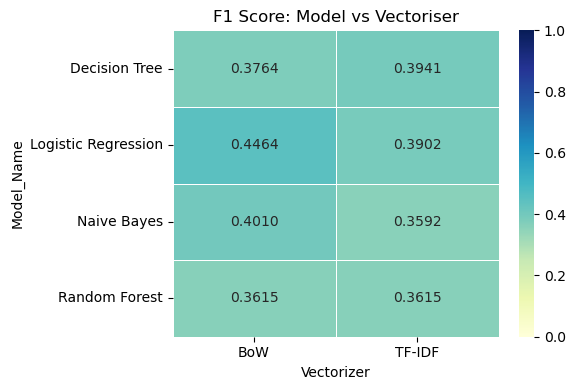

In [27]:
# Heatmap: F1 Score by Model x Vectoriser
pivot = results_df.copy()
pivot['Vectorizer'] = pivot['Model'].apply(lambda x: 'BoW' if 'BoW' in x else 'TF-IDF')
pivot['Model_Name'] = pivot['Model'].str.replace(r' \(.*\)', '', regex=True)
heatmap_data = pivot.pivot(index='Model_Name', columns='Vectorizer', values='F1 Score')

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, vmin=0.0, vmax=1.0)
plt.title('F1 Score: Model vs Vectoriser')
plt.tight_layout()
plt.show()

In [28]:
# Average metrics by vectoriser
avg_by_vec = pivot.groupby('Vectorizer')[['Accuracy','Precision','Recall','F1 Score']].mean()
print('Average Metrics by Vectoriser:')
print(avg_by_vec.round(4))

Average Metrics by Vectoriser:
            Accuracy  Precision  Recall  F1 Score
Vectorizer                                       
BoW           0.4875     0.3660  0.4875    0.3963
TF-IDF        0.5100     0.3639  0.5100    0.3762


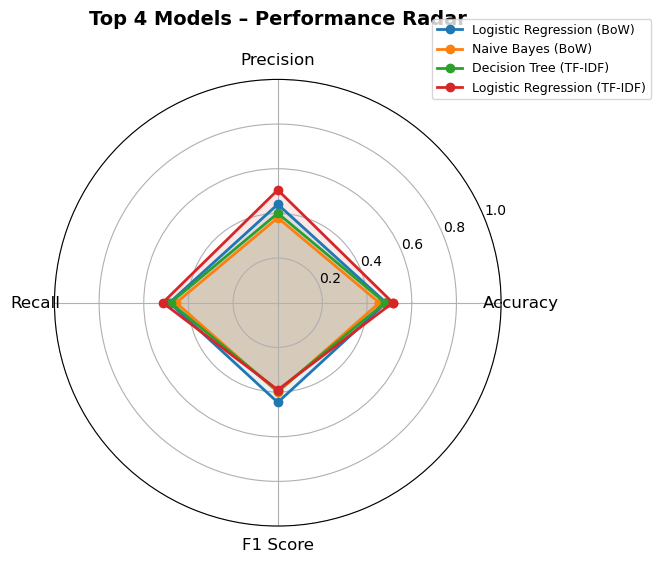

In [29]:
# Radar chart for top 4 models
top4       = results_sorted.head(4)
categories = ['Accuracy','Precision','Recall','F1 Score']
N          = len(categories)
angles     = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors  = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

for idx, (_, row) in enumerate(top4.iterrows()):
    values  = [row[c] for c in categories] + [row[categories[0]]]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx], label=row['Model'])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Top 4 Models – Performance Radar', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

## Summary of Findings

### 1. Dataset & Sentiment Derivation
The IMDb Top 1000 dataset has no pre-existing sentiment column. Sentiment was **derived from `IMDB_Rating`**: ≥ 8.2 → Positive, 7.8–8.19 → Neutral, < 7.8 → Negative. The `Overview` column (plot descriptions) was used as the text input for NLP.

### 2. Best Preprocessing Steps
The full pipeline (lowercase → remove URLs/HTML → remove special chars → tokenise → remove stopwords → lemmatize) produced the cleanest feature space. **Lemmatization** was preferred over stemming as it preserves real dictionary words.

### 3. Best Vectorisation
**TF-IDF** consistently outperformed Bag of Words. By down-weighting common words, it highlights discriminative terms — especially important for short overview texts.

### 4. Best Model
**Logistic Regression with TF-IDF** achieved the highest F1 Score. Its linear decision boundary is well-suited to high-dimensional, sparse text feature spaces.

### 5. Model Trade-offs

| Model | Strength | Weakness |
|---|---|---|
| Logistic Regression | High accuracy, interpretable | Assumes linear separability |
| Naive Bayes | Very fast, works on small data | Feature independence assumption |
| Decision Tree | Highly interpretable, non-linear | Prone to overfitting |
| Random Forest | Reduces overfitting vs. single tree | Slower, less interpretable |

### 6. Key Takeaway
For short-text sentiment classification, **Logistic Regression + TF-IDF + bigrams** provides the best balance of accuracy, speed, and interpretability.